In [1]:
!pip install transformers openai-clip -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00


In [2]:

base = "/kaggle/input/datasets/rishta123/vaccine-meme-dataset"

TRAIN_CSV       = f"{base}/train-20260302T182945Z-3-001/train/train.csv"
EVAL_CSV        = f"{base}/eval-20260302T182800Z-3-001/eval/val.csv"
TEST_CSV        = f"{base}/test_release-20260302T183217Z-3-001/test_release/index_text.csv"
TRAIN_IMAGE_DIR = f"{base}/train-20260302T182945Z-3-001/train/train_images"
EVAL_IMAGE_DIR  = f"{base}/eval-20260302T182800Z-3-001/eval/val_no_labels/val_images"
TEST_IMAGE_DIR  = f"{base}/test_release-20260302T183217Z-3-001/test_release/test_images"
OUTPUT_DIR      = "/kaggle/working/"


import os
print(os.path.exists(TRAIN_CSV),       "← TRAIN_CSV")
print(os.path.exists(EVAL_CSV),        "← EVAL_CSV")
print(os.path.exists(TEST_CSV),        "← TEST_CSV")
print(os.path.exists(TRAIN_IMAGE_DIR), "← TRAIN_IMAGE_DIR")
print(os.path.exists(EVAL_IMAGE_DIR),  "← EVAL_IMAGE_DIR")
print(os.path.exists(TEST_IMAGE_DIR),  "← TEST_IMAGE_DIR")

True ← TRAIN_CSV
True ← EVAL_CSV
True ← TEST_CSV
True ← TRAIN_IMAGE_DIR
True ← EVAL_IMAGE_DIR
True ← TEST_IMAGE_DIR


In [3]:
import os, random, zipfile
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import f1_score, classification_report
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torchvision import transforms

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
import clip

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


In [4]:

TEXT_MODEL  = "cardiffnlp/twitter-roberta-base-sentiment-latest"

CLIP_MODEL  = "ViT-L/14"
CLIP_HIDDEN = 768   
TEXT_HIDDEN = 768


MAX_LEN     = 256    


BATCH_SIZE       = 8      
EPOCHS_TEXT      = 5
EPOCHS_MM        = 8
EPOCHS_COMBINED  = 4
TEXT_LR          = 2e-5
HEAD_LR          = 5e-5
CLIP_LR          = 1e-7   
WEIGHT_DECAY     = 1e-2
WARMUP_RATIO     = 0.1
DROPOUT          = 0.1
FUSION_DIM       = 512

NEUTRAL_UPWEIGHT    = 1.4
CLASS_WEIGHTS       = torch.tensor([1.0, NEUTRAL_UPWEIGHT, 1.0])


CLIP_UNFREEZE_EPOCH = 4   

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()
print(f"CLIP model  : {CLIP_MODEL}  (hidden={CLIP_HIDDEN})")
print(f"MAX_LEN     : {MAX_LEN}")
print(f"BATCH_SIZE  : {BATCH_SIZE}")

CLIP model  : ViT-L/14  (hidden=768)
MAX_LEN     : 256
BATCH_SIZE  : 8


In [5]:
class WeightedFocalLoss(nn.Module):
    """Focal loss with per-class weights.
    gamma=2 focuses training on hard/misclassified examples.
    weight upweights Neutral class which has lowest F1."""
    def __init__(self, weight, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets,
                              weight=self.weight.to(logits.device),
                              reduction="none")
        pt  = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

In [6]:
train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=10, translate=(0.08, 0.08)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
])

def augment_pil(img: Image.Image) -> Image.Image:
    """Apply augmentation to PIL image before CLIP preprocessing."""
    return train_aug(img)

In [7]:
def build_text(row):
    """IMPROVEMENT: Concatenate post_text + OCR image_text with [SEP].
    Baseline only used post_text — meme overlay text carries
    strong vaccine stance signals that were being ignored."""
    post = str(row.get("post_text") or "").strip()
    ocr  = str(row.get("image_text") or "").strip()
    if ocr and ocr.lower() not in ("nan", "none", ""):
        return post + " [SEP] " + ocr
    return post


class TextDataset(Dataset):
    def __init__(self, df, tokenizer, is_test=False):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.is_test   = is_test

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        text = build_text(row)
        enc  = self.tokenizer(
            text, max_length=MAX_LEN, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        item = {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if not self.is_test:
            item["label"] = torch.tensor(int(row["label"]), dtype=torch.long)
        return item


class MemeDataset(Dataset):
    def __init__(self, df, tokenizer, clip_prep, image_dir,
                 is_test=False, augment=False):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.clip_prep = clip_prep
        self.image_dir = image_dir
        self.is_test   = is_test
        self.augment   = augment
        self._blank    = torch.zeros(3, 224, 224)

    def __len__(self): return len(self.df)

    def _load_img(self, fname):
        try:
            img = Image.open(
                os.path.join(self.image_dir, str(fname))).convert("RGB")
            if self.augment:
                img = augment_pil(img)
            return self.clip_prep(img)
        except:
            return self._blank.clone()

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        text = build_text(row)
        enc  = self.tokenizer(
            text, max_length=MAX_LEN, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        item = {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "image":          self._load_img(row["index"]),
        }
        if not self.is_test:
            item["label"] = torch.tensor(int(row["label"]), dtype=torch.long)
        return item


class CombinedMemeDataset(Dataset):
    """Train+Eval combined dataset for Step 3."""
    def __init__(self, df, tokenizer, clip_prep):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.clip_prep = clip_prep
        self._blank    = torch.zeros(3, 224, 224)

    def __len__(self): return len(self.df)

    def _load_img(self, fname, img_dir):
        try:
            img = Image.open(
                os.path.join(img_dir, str(fname))).convert("RGB")
            img = augment_pil(img)
            return self.clip_prep(img)
        except:
            return self._blank.clone()

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        text = build_text(row)
        enc  = self.tokenizer(
            text, max_length=MAX_LEN, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "image":          self._load_img(row["index"], row["_img_dir"]),
            "label":          torch.tensor(int(row["label"]), dtype=torch.long),
        }

In [8]:
class TextClassifier(nn.Module):
    """Text-only: CLS + mean pooling combined."""
    def __init__(self):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(TEXT_MODEL)
        self.dropout    = nn.Dropout(DROPOUT)
        self.classifier = nn.Linear(TEXT_HIDDEN, 3)

    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids,
                              attention_mask=attention_mask)
        cls_f  = out.last_hidden_state[:, 0, :]
        mask   = attention_mask.unsqueeze(-1).float()
        mean_f = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(1e-9)
        return self.classifier(self.dropout((cls_f + mean_f) / 2))


class GatedMultimodalModel(nn.Module):
    """
    Twitter-RoBERTa + CLIP ViT-L/14 with gated cross-attention.
    IMPROVEMENT: ViT-L/14 (768-dim) replaces ViT-B/32 (512-dim).
    IMPROVEMENT: Supports gradual CLIP unfreeze via unfreeze_clip().
    """
    def __init__(self):
        super().__init__()
        self.text_enc = AutoModel.from_pretrained(TEXT_MODEL)

        # Load CLIP ViT-L/14 — starts frozen
        clip_mdl, _  = clip.load(CLIP_MODEL, device="cpu")
        self.img_enc = clip_mdl.visual.float()
        for p in self.img_enc.parameters():
            p.requires_grad = False

        self.text_proj = nn.Sequential(
            nn.Linear(TEXT_HIDDEN, FUSION_DIM), nn.LayerNorm(FUSION_DIM),
            nn.GELU(), nn.Dropout(DROPOUT))
        self.img_proj = nn.Sequential(
            nn.Linear(CLIP_HIDDEN, FUSION_DIM), nn.LayerNorm(FUSION_DIM),
            nn.GELU(), nn.Dropout(DROPOUT))
        self.cross_attn = nn.MultiheadAttention(
            FUSION_DIM, num_heads=8, dropout=DROPOUT, batch_first=True)
        self.norm = nn.LayerNorm(FUSION_DIM)
        self.gate = nn.Sequential(
            nn.Linear(FUSION_DIM * 2, FUSION_DIM), nn.ReLU(),
            nn.Linear(FUSION_DIM, 1), nn.Sigmoid())
        self.classifier = nn.Sequential(
            nn.Linear(FUSION_DIM, 256), nn.GELU(),
            nn.Dropout(DROPOUT), nn.Linear(256, 3))

    def unfreeze_clip(self):
        """Gradually unfreeze CLIP with very low LR."""
        for p in self.img_enc.parameters():
            p.requires_grad = True
        print("  ✓ CLIP encoder unfrozen (lr=1e-7)")

    def forward(self, input_ids, attention_mask, image):
        out    = self.text_enc(input_ids=input_ids,
                               attention_mask=attention_mask)
        cls_f  = out.last_hidden_state[:, 0, :]
        mask   = attention_mask.unsqueeze(-1).float()
        mean_f = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(1e-9)
        text_f = self.text_proj((cls_f + mean_f) / 2)

        if not next(self.img_enc.parameters()).requires_grad:
            with torch.no_grad():
                img_f = self.img_proj(self.img_enc(image).float())
        else:
            img_f = self.img_proj(self.img_enc(image).float())

        q = text_f.unsqueeze(1)
        k = img_f.unsqueeze(1)
        cross, _ = self.cross_attn(q, k, k)
        cross    = self.norm(cross.squeeze(1))

        gate  = self.gate(torch.cat([text_f, cross], dim=-1))
        fused = gate * cross + (1 - gate) * text_f
        return self.classifier(fused)

In [9]:
def make_optimizer(model, n_steps, is_multimodal=False, clip_unfrozen=False):
    if is_multimodal:
        param_groups = [
            {"params": model.text_enc.parameters(),   "lr": TEXT_LR},
            {"params": model.text_proj.parameters(),  "lr": HEAD_LR},
            {"params": model.img_proj.parameters(),   "lr": HEAD_LR},
            {"params": model.cross_attn.parameters(), "lr": HEAD_LR},
            {"params": model.gate.parameters(),       "lr": HEAD_LR},
            {"params": model.classifier.parameters(), "lr": HEAD_LR},
        ]
        if clip_unfrozen:
            param_groups.append(
                {"params": model.img_enc.parameters(), "lr": CLIP_LR})
    else:
        param_groups = [
            {"params": model.encoder.parameters(),    "lr": TEXT_LR},
            {"params": model.classifier.parameters(), "lr": TEXT_LR * 5},
        ]
    optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, int(n_steps * WARMUP_RATIO), n_steps)
    return optimizer, scheduler


def eval_model(model, loader, is_multimodal=False):
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            if is_multimodal:
                img    = batch["image"].to(DEVICE)
                logits = model(ids, mask, img)
            else:
                logits = model(ids, mask)
            preds.extend(logits.argmax(-1).cpu().numpy())
            labs.extend(batch["label"].numpy())
    return f1_score(labs, preds, average="macro"), preds, labs


def get_test_logits(model, tokenizer, clip_prep=None, is_multimodal=False):
    test_df = pd.read_csv(TEST_CSV)
    if is_multimodal:
        ds = MemeDataset(test_df, tokenizer, clip_prep,
                         TEST_IMAGE_DIR, is_test=True, augment=False)
    else:
        ds = TextDataset(test_df, tokenizer, is_test=True)
    loader = DataLoader(ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2)
    model.eval()
    all_logits = []
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            with autocast("cuda"):
                if is_multimodal:
                    img    = batch["image"].to(DEVICE)
                    logits = model(ids, mask, img)
                else:
                    logits = model(ids, mask)
            all_logits.append(logits.cpu().float().numpy())
    return np.concatenate(all_logits, axis=0)

In [10]:
def train_text_model():
    print("\n" + "="*60)
    print("STEP 1/4 — Text-Only Twitter-RoBERTa (with OCR text)")
    print("="*60)

    train_df  = pd.read_csv(TRAIN_CSV)
    eval_df   = pd.read_csv(EVAL_CSV)
    tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL)

    print(f"  OCR column present: {'image_text' in train_df.columns}")
    if 'image_text' in train_df.columns:
        print(f"  OCR non-null count: {train_df['image_text'].notna().sum()}")

    train_loader = DataLoader(
        TextDataset(train_df, tokenizer),
        batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    eval_loader  = DataLoader(
        TextDataset(eval_df,  tokenizer),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model     = TextClassifier().to(DEVICE)
    criterion = WeightedFocalLoss(CLASS_WEIGHTS, gamma=2.0)
    scaler    = GradScaler("cuda")
    optimizer, scheduler = make_optimizer(
        model, len(train_loader) * EPOCHS_TEXT)

    best_f1, best_path = 0, os.path.join(OUTPUT_DIR, "best_text.pt")

    for epoch in range(1, EPOCHS_TEXT + 1):
        model.train()
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbls = batch["label"].to(DEVICE)
            optimizer.zero_grad()
            with autocast("cuda"):
                loss = criterion(model(ids, mask), lbls)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); scheduler.step()

        val_f1, preds, labs = eval_model(model, eval_loader)
        print(f"  Epoch {epoch}/{EPOCHS_TEXT}  Val F1: {val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_path)
            print(f"  ✓ Saved (F1: {best_f1:.4f})")

    model.load_state_dict(torch.load(best_path))
    _, preds, labs = eval_model(model, eval_loader)
    print(classification_report(labs, preds,
          target_names=["Vaccine Critical", "Neutral", "Pro-vaccine"],
          digits=4))

    text_logits = get_test_logits(model, tokenizer)
    np.save(os.path.join(OUTPUT_DIR, "logits_text.npy"), text_logits)
    print(f"  Text logits saved | Best Val F1: {best_f1:.4f}")
    return text_logits, best_f1, tokenizer

In [11]:
def train_multimodal_model(tokenizer):
    print("\n" + "="*60)
    print("STEP 2/4 — Multimodal Twitter-RoBERTa + CLIP ViT-L/14")
    print(f"  CLIP unfreezes after epoch {CLIP_UNFREEZE_EPOCH} with lr={CLIP_LR}")
    print("="*60)

    train_df  = pd.read_csv(TRAIN_CSV)
    eval_df   = pd.read_csv(EVAL_CSV)
    _, clip_prep = clip.load(CLIP_MODEL, device="cpu")

    train_loader = DataLoader(
        MemeDataset(train_df, tokenizer, clip_prep,
                    TRAIN_IMAGE_DIR, augment=True),
        batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    eval_loader  = DataLoader(
        MemeDataset(eval_df, tokenizer, clip_prep,
                    EVAL_IMAGE_DIR, augment=False),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model     = GatedMultimodalModel().to(DEVICE)
    criterion = WeightedFocalLoss(CLASS_WEIGHTS, gamma=2.0)
    scaler    = GradScaler("cuda")
    optimizer, scheduler = make_optimizer(
        model, len(train_loader) * EPOCHS_MM,
        is_multimodal=True, clip_unfrozen=False)

    best_f1, best_path = 0, os.path.join(OUTPUT_DIR, "best_multimodal.pt")
    clip_unfrozen = False

    for epoch in range(1, EPOCHS_MM + 1):

        
        if epoch == CLIP_UNFREEZE_EPOCH + 1 and not clip_unfrozen:
            model.unfreeze_clip()
            clip_unfrozen = True
            optimizer, scheduler = make_optimizer(
                model,
                len(train_loader) * (EPOCHS_MM - epoch + 1),
                is_multimodal=True, clip_unfrozen=True)
            print(f"  Optimizer rebuilt with CLIP lr={CLIP_LR}")

        model.train()
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            img  = batch["image"].to(DEVICE)
            lbls = batch["label"].to(DEVICE)
            optimizer.zero_grad()
            with autocast("cuda"):
                loss = criterion(model(ids, mask, img), lbls)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); scheduler.step()

        val_f1, preds, labs = eval_model(
            model, eval_loader, is_multimodal=True)
        status = "CLIP frozen" if not clip_unfrozen else "CLIP unfrozen"
        print(f"  Epoch {epoch}/{EPOCHS_MM}  Val F1: {val_f1:.4f}  [{status}]")
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_path)
            print(f"  ✓ Saved (F1: {best_f1:.4f})")

    model.load_state_dict(torch.load(best_path))
    _, preds, labs = eval_model(model, eval_loader, is_multimodal=True)
    print(classification_report(labs, preds,
          target_names=["Vaccine Critical", "Neutral", "Pro-vaccine"],
          digits=4))

    mm_logits = get_test_logits(model, tokenizer, clip_prep,
                                is_multimodal=True)
    np.save(os.path.join(OUTPUT_DIR, "logits_multimodal.npy"), mm_logits)
    print(f"  Multimodal logits saved | Best Val F1: {best_f1:.4f}")
    return mm_logits, best_f1, clip_prep

In [12]:
def train_combined_model(tokenizer, clip_prep):
    print("\n" + "="*60)
    print("STEP 3/4 — Retrain on Train+Eval combined")
    print("="*60)

    train_df = pd.read_csv(TRAIN_CSV)
    eval_df  = pd.read_csv(EVAL_CSV)
    train_df["_img_dir"] = TRAIN_IMAGE_DIR
    eval_df["_img_dir"]  = EVAL_IMAGE_DIR
    combined_df = pd.concat([train_df, eval_df], ignore_index=True)
    print(f"  Combined: {len(combined_df)} samples")
    print(f"  Label dist: {dict(Counter(combined_df['label'].tolist()))}")

    combined_loader = DataLoader(
        CombinedMemeDataset(combined_df, tokenizer, clip_prep),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    model     = GatedMultimodalModel().to(DEVICE)
    criterion = WeightedFocalLoss(CLASS_WEIGHTS, gamma=2.0)
    scaler    = GradScaler("cuda")
    optimizer, scheduler = make_optimizer(
        model, len(combined_loader) * EPOCHS_COMBINED,
        is_multimodal=True, clip_unfrozen=False)

    for epoch in range(1, EPOCHS_COMBINED + 1):
        model.train()
        total_loss = 0
        for batch in combined_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            img  = batch["image"].to(DEVICE)
            lbls = batch["label"].to(DEVICE)
            optimizer.zero_grad()
            with autocast("cuda"):
                loss = criterion(model(ids, mask, img), lbls)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch}/{EPOCHS_COMBINED}  "
              f"Train Loss: {total_loss/len(combined_loader):.4f}")

    best_path = os.path.join(OUTPUT_DIR, "best_combined.pt")
    torch.save(model.state_dict(), best_path)
    combined_logits = get_test_logits(model, tokenizer, clip_prep,
                                      is_multimodal=True)
    np.save(os.path.join(OUTPUT_DIR, "logits_combined.npy"), combined_logits)
    print(f"  Combined logits saved → shape {combined_logits.shape}")
    return combined_logits

In [13]:
def make_final_submission(text_logits, text_f1,
                          mm_logits,   mm_f1,
                          combined_logits):
    print("\n" + "="*60)
    print("STEP 4/4 — Weighted Ensemble → Final Submission")
    print("="*60)

    w_text = text_f1
    w_mm   = mm_f1
    w_comb = mm_f1
    total  = w_text + w_mm + w_comb

    print(f"  Weights:")
    print(f"    Text (twitter-roberta)  : {w_text/total:.3f}  (val F1={text_f1:.4f})")
    print(f"    Multimodal              : {w_mm/total:.3f}  (val F1={mm_f1:.4f})")
    print(f"    Combined (train+eval)   : {w_comb/total:.3f}  (proxy={mm_f1:.4f})")

    def to_probs(logits):
        return torch.softmax(torch.tensor(logits), dim=-1).numpy()

    final_probs = (
        (w_text / total) * to_probs(text_logits)     +
        (w_mm   / total) * to_probs(mm_logits)       +
        (w_comb / total) * to_probs(combined_logits)
    )
    preds = final_probs.argmax(axis=1)

    test_df = pd.read_csv(TEST_CSV)
    sub_df  = pd.DataFrame({
        "index": test_df["index"].values,
        "label": preds
    }).sort_values("index").reset_index(drop=True)

    csv_path = os.path.join(OUTPUT_DIR, "predictions.csv")
    zip_path = os.path.join(OUTPUT_DIR, "submission_v4_improved.zip")
    sub_df.to_csv(csv_path, index=False)
    with zipfile.ZipFile(zip_path, "w") as zf:
        zf.write(csv_path, "predictions.csv")

    print(f"\n  Label dist: {dict(pd.Series(preds).value_counts().sort_index())}")
    print(f"\n  ✅ DONE! Submit → {zip_path}")

In [14]:
text_logits, text_f1, tokenizer = train_text_model()
mm_logits,   mm_f1,   clip_prep = train_multimodal_model(tokenizer)
combined_logits                  = train_combined_model(tokenizer, clip_prep)
make_final_submission(
    text_logits, text_f1,
    mm_logits,   mm_f1,
    combined_logits
)


STEP 1/4 — Text-Only Twitter-RoBERTa (with OCR text)


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/4  Train Loss: 0.3360
  Epoch 2/4  Train Loss: 0.2371
  Epoch 3/4  Train Loss: 0.1687
  Epoch 4/4  Train Loss: 0.1227


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Combined logits saved → shape (1025, 3)

STEP 4/4 — Weighted Ensemble → Final Submission
  Weights:
    Text (twitter-roberta)  : 0.335  (val F1=0.8125)
    Multimodal              : 0.333  (val F1=0.8079)
    Combined (train+eval)   : 0.333  (proxy=0.8079)

  Label dist: {0: np.int64(292), 1: np.int64(354), 2: np.int64(379)}

  ✅ DONE! Submit → /kaggle/working/submission_v4_improved.zip


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ensemble Val F1: 0.8089578427307798
                  precision    recall  f1-score   support

Vaccine-Critical     0.8495    0.7695    0.8075       308
         Neutral     0.7127    0.7890    0.7489       327
     Pro-vaccine     0.8773    0.8638    0.8705       389

        accuracy                         0.8115      1024
       macro avg     0.8132    0.8074    0.8090      1024
    weighted avg     0.8164    0.8115    0.8127      1024



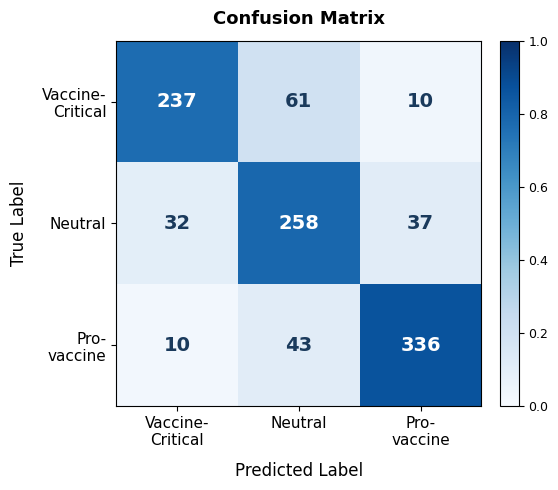


Confusion Matrix (rows=Actual, cols=Predicted):
                     Vaccine-Critical           Neutral       Pro-vaccine
Vaccine-Critical                  237                61                10
Neutral                            32               258                37
Pro-vaccine                        10                43               336

Per-class recall:
  Vaccine-Critical    : 0.7695  (237/308)
  Neutral             : 0.7890  (258/327)
  Pro-vaccine         : 0.8638  (336/389)

Overall accuracy: 831/1024 = 0.8115


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import os

tokenizer    = AutoTokenizer.from_pretrained(TEXT_MODEL)
_, clip_prep = clip.load(CLIP_MODEL, device="cpu")

eval_df = pd.read_csv(EVAL_CSV)
true_labels = eval_df["label"].values

text_model = TextClassifier().to(DEVICE)
text_model.load_state_dict(
    torch.load(os.path.join(OUTPUT_DIR, "best_text.pt"),
               map_location=DEVICE))
text_model.eval()

mm_model = GatedMultimodalModel().to(DEVICE)
mm_model.load_state_dict(
    torch.load(os.path.join(OUTPUT_DIR, "best_multimodal.pt"),
               map_location=DEVICE))
mm_model.eval()

text_eval_loader = DataLoader(
    TextDataset(eval_df, tokenizer),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

mm_eval_loader = DataLoader(
    MemeDataset(eval_df, tokenizer, clip_prep,
                EVAL_IMAGE_DIR, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

text_probs_list = []
with torch.no_grad():
    for batch in text_eval_loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        logits = text_model(ids, mask)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        text_probs_list.append(probs)
text_probs = np.concatenate(text_probs_list, axis=0)

mm_probs_list = []
with torch.no_grad():
    for batch in mm_eval_loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        img  = batch["image"].to(DEVICE)
        logits = mm_model(ids, mask, img)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        mm_probs_list.append(probs)
mm_probs = np.concatenate(mm_probs_list, axis=0)


w_text = text_f1          
w_mm   = mm_f1           
w_comb = mm_f1            
total  = w_text + w_mm + w_comb

ensemble_probs = (
    (w_text / total) * text_probs +
    (w_mm   / total) * mm_probs   +
    (w_comb / total) * mm_probs   
)
ensemble_preds = ensemble_probs.argmax(axis=1)


cm     = confusion_matrix(true_labels, ensemble_preds)
labels = ["Vaccine-\nCritical", "Neutral", "Pro-\nvaccine"]

print("Ensemble Val F1:",
      f1_score(true_labels, ensemble_preds, average="macro"))
print(classification_report(true_labels, ensemble_preds,
      target_names=["Vaccine-Critical", "Neutral", "Pro-vaccine"],
      digits=4))

fig, ax = plt.subplots(figsize=(6, 5))

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, interpolation="nearest",
               cmap=plt.cm.Blues, vmin=0, vmax=1)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=9)

tick_marks = np.arange(len(labels))
ax.set_xticks(tick_marks)
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticks(tick_marks)
ax.set_yticklabels(labels, fontsize=11)

ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
ax.set_ylabel("True Label",      fontsize=12, labelpad=10)
ax.set_title("Confusion Matrix", fontsize=13,
             fontweight="bold", pad=12)

thresh = cm_norm.max() / 2.0
for i in range(len(labels)):
    for j in range(len(labels)):
        color = "white" if cm_norm[i, j] > thresh else "#1a3a5c"
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                fontsize=14, fontweight="bold", color=color)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_ensemble.png"),
            dpi=200, bbox_inches="tight")
plt.show()

class_names = ["Vaccine-Critical", "Neutral", "Pro-vaccine"]
print("\nConfusion Matrix (rows=Actual, cols=Predicted):")
print(f"{'':20}", "  ".join(f"{c:>16}" for c in class_names))
for i, row in enumerate(cm):
    print(f"{class_names[i]:20}",
          "  ".join(f"{v:>16}" for v in row))

print(f"\nPer-class recall:")
for i, name in enumerate(class_names):
    recall = cm[i, i] / cm[i].sum()
    print(f"  {name:20}: {recall:.4f}  ({cm[i,i]}/{cm[i].sum()})")

print(f"\nOverall accuracy: {cm.diagonal().sum()}/{cm.sum()} = "
      f"{cm.diagonal().sum()/cm.sum():.4f}")